# Pandas basics

Notes from the MLP course pandas sessions, cleaned up and combined with the bits of the
[official pandas cheat sheet](https://pandas.pydata.org/Pandas_Cheat_Sheet.pdf) that I kept going back to.

Covers:
1. Series and DataFrames
2. Exploring a dataset
3. Selecting rows and columns (`[]`, `.loc`, `.iloc`, boolean masks)
4. Adding, changing and dropping data
5. Missing values
6. Aggregation and `groupby`
7. Reshaping and combining DataFrames
8. Quick plots

Most of it runs on the sklearn diabetes dataset so there's no file to upload.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.datasets import load_diabetes

pd.__version__

'3.0.5'

## 1. Series and DataFrames

Two main objects:

* `Series` - one column of values with an index (row labels).
* `DataFrame` - a table. Each column is a Series, and they all share the same index.

In [2]:
cities = pd.Series(['Mumbai', 'Bangalore', 'Chennai', 'Delhi'])
population = pd.Series([17_000_000, 13_000_000, 6_000_000])

city_info_df = pd.DataFrame({'City': cities, 'Population': population})
city_info_df

,City,Population
0,Mumbai,17000000.0
1,Bangalore,13000000.0
2,Chennai,6000000.0
3,Delhi,NaN


`population` only had 3 values, so Delhi gets `NaN`. Pandas lines the Series up by index, it doesn't
complain about the length mismatch. The column also became `float64` because `NaN` is a float.

Other ways to build one, by column or by row:

In [3]:
by_column = pd.DataFrame(
    {'a': [4, 5, 6],
     'b': [7, 8, 9],
     'c': [10, 11, 12]},
    index=[1, 2, 3])

by_row = pd.DataFrame(
    [[4, 7, 10],
     [5, 8, 11],
     [6, 9, 12]],
    index=[1, 2, 3],
    columns=['a', 'b', 'c'])

by_column.equals(by_row)

True

In [4]:
# from a numpy array, with a custom index
rand_df = pd.DataFrame(np.random.rand(5, 4),
                       index=range(10, 15),
                       columns=list('ABCD'))
rand_df

,A,B,C,D
10,0.997316,0.541821,0.054107,0.609181
11,0.170387,0.250236,0.202758,0.795538
12,0.371296,0.715348,0.099693,0.914328
13,0.787553,0.853605,0.761636,0.846063
14,0.780157,0.657379,0.193521,0.948365


## 2. Exploring a dataset

sklearn's diabetes data: 442 patients, 10 baseline features and a target that measures disease progression
one year later.

By default sklearn returns the features already mean-centred and scaled, which makes them hard to read
(age = 0.038?). `scaled=False` gives the original values, which are much easier to reason about when
filtering.

In [5]:
diabetes = load_diabetes(as_frame=True, scaled=False)
df = diabetes.frame          # features + 'target' in one DataFrame
type(df)

pandas.DataFrame

In [6]:
print(diabetes.DESCR[:1500])

.. _diabetes_dataset:

Diabetes dataset
----------------

Ten baseline variables, age, sex, body mass index, average blood
pressure, and six blood serum measurements were obtained for each of n =
442 diabetes patients, as well as the response of interest, a
quantitative measure of disease progression one year after baseline.

**Data Set Characteristics:**

:Number of Instances: 442

:Number of Attributes: First 10 columns are numeric predictive values

:Target: Column 11 is a quantitative measure of disease progression one year after baseline

:Attribute Information:
    - age     age in years
    - sex
    - bmi     body mass index
    - bp      average blood pressure
    - s1      tc, total serum cholesterol
    - s2      ldl, low-density lipoproteins
    - s3      hdl, high-density lipoproteins
    - s4      tch, total cholesterol / HDL
    - s5      ltg, possibly log of serum triglycerides level
    - s6      glu, blood sugar level

Note: Each of these 10 feature variables have bee

Column meanings (from the description): `bmi` body mass index, `bp` average blood pressure,
`s1`-`s6` are blood serum measurements, `sex` is coded as 1 / 2.

In Colab, `?load_diabetes` or `help(pd.DataFrame.head)` brings up the docstring for anything.

In [7]:
df.shape

(442, 11)

In [8]:
df.columns.tolist()

['age', 'sex', 'bmi', 'bp', 's1', 's2', 's3', 's4', 's5', 's6', 'target']

In [9]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 442 entries, 0 to 441
Data columns (total 11 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   age     442 non-null    float64
 1   sex     442 non-null    float64
 2   bmi     442 non-null    float64
 3   bp      442 non-null    float64
 4   s1      442 non-null    float64
 5   s2      442 non-null    float64
 6   s3      442 non-null    float64
 7   s4      442 non-null    float64
 8   s5      442 non-null    float64
 9   s6      442 non-null    float64
 10  target  442 non-null    float64
dtypes: float64(11)
memory usage: 38.1 KB


In [10]:
df.head()

,age,sex,bmi,bp,s1,s2,s3,s4,s5,s6,target
0,59.0,2.0,32.1,101.0,157.0,93.2,38.0,4.0,4.8598,87.0,151.0
1,48.0,1.0,21.6,87.0,183.0,103.2,70.0,3.0,3.8918,69.0,75.0
2,72.0,2.0,30.5,93.0,156.0,93.6,41.0,4.0,4.6728,85.0,141.0
3,24.0,1.0,25.3,84.0,198.0,131.4,40.0,5.0,4.8903,89.0,206.0
4,50.0,1.0,23.0,101.0,192.0,125.4,52.0,4.0,4.2905,80.0,135.0


In [11]:
df.tail(3)

,age,sex,bmi,bp,s1,s2,s3,s4,s5,s6,target
439,60.0,2.0,24.9,99.67,162.0,106.6,43.0,3.77,4.1271,95.0,132.0
440,36.0,1.0,30.0,95.00,201.0,125.2,42.0,4.79,5.1299,85.0,220.0
441,36.0,1.0,19.6,71.00,250.0,133.2,97.0,3.00,4.5951,92.0,57.0


In [12]:
df.describe()

,age,sex,bmi,bp,s1,s2,s3,s4,s5,s6,target
count,442.000000,442.000000,442.000000,442.000000,442.000000,442.000000,442.000000,442.000000,442.000000,442.000000,442.000000
mean,48.518100,1.468326,26.375792,94.647014,189.140271,115.439140,49.788462,4.070249,4.641411,91.260181,152.133484
std,13.109028,0.499561,4.418122,13.831283,34.608052,30.413081,12.934202,1.290450,0.522391,11.496335,77.093005
min,19.000000,1.000000,18.000000,62.000000,97.000000,41.600000,22.000000,2.000000,3.258100,58.000000,25.000000
25%,38.250000,1.000000,23.200000,84.000000,164.250000,96.050000,40.250000,3.000000,4.276700,83.250000,87.000000
50%,50.000000,1.000000,25.700000,93.000000,186.000000,113.000000,48.000000,4.000000,4.620050,91.000000,140.500000
75%,59.000000,2.000000,29.275000,105.000000,209.750000,134.500000,57.750000,5.000000,4.997200,98.000000,211.500000
max,79.000000,2.000000,42.200000,133.000000,301.000000,242.400000,99.000000,9.090000,6.107000,124.000000,346.000000


Transposing is easier to read when there are a lot of columns. You can also choose your own percentiles.

In [13]:
df.describe(percentiles=[0.2, 0.6, 0.8]).T

,count,mean,std,min,20%,60%,80%,max
age,442.0,48.518100,13.109028,19.0000,36.0000,53.0000,60.00000,79.000
sex,442.0,1.468326,0.499561,1.0000,1.0000,2.0000,2.00000,2.000
bmi,442.0,26.375792,4.418122,18.0000,22.6200,26.8600,30.30000,42.200
bp,442.0,94.647014,13.831283,62.0000,83.0000,97.0000,109.00000,133.000
s1,442.0,189.140271,34.608052,97.0000,161.0000,195.0000,217.80000,301.000
s2,442.0,115.439140,30.413081,41.6000,91.8400,121.0000,140.68000,242.400
s3,442.0,49.788462,12.934202,22.0000,39.0000,52.0000,60.00000,99.000
s4,442.0,4.070249,1.290450,2.0000,3.0000,4.0000,5.00000,9.090
s5,442.0,4.641411,0.522391,3.2581,4.1897,4.7791,5.06764,6.107
s6,442.0,91.260181,11.496335,58.0000,82.0000,93.0000,100.00000,124.000


In [14]:
df['sex'].value_counts()

sex
1.0    235
2.0    207
Name: count, dtype: int64

## 3. Selection

### Columns

In [15]:
df['age']        # one column -> Series

0      59.0
1      48.0
2      72.0
3      24.0
4      50.0
       ... 
437    60.0
438    47.0
439    60.0
440    36.0
441    36.0
Name: age, Length: 442, dtype: float64

In [16]:
type(df['age']), type(df[['age']])

(pandas.Series, pandas.DataFrame)

In [17]:
df[['age', 'sex', 'bmi']].head()   # list of columns -> DataFrame

,age,sex,bmi
0,59.0,2.0,32.1
1,48.0,1.0,21.6
2,72.0,2.0,30.5
3,24.0,1.0,25.3
4,50.0,1.0,23.0


Slicing with `[]` and a range selects **rows**, not columns. Easy to forget.

In [18]:
df[:5]

,age,sex,bmi,bp,s1,s2,s3,s4,s5,s6,target
0,59.0,2.0,32.1,101.0,157.0,93.2,38.0,4.0,4.8598,87.0,151.0
1,48.0,1.0,21.6,87.0,183.0,103.2,70.0,3.0,3.8918,69.0,75.0
2,72.0,2.0,30.5,93.0,156.0,93.6,41.0,4.0,4.6728,85.0,141.0
3,24.0,1.0,25.3,84.0,198.0,131.4,40.0,5.0,4.8903,89.0,206.0
4,50.0,1.0,23.0,101.0,192.0,125.4,52.0,4.0,4.2905,80.0,135.0


In [19]:
df['age'][100:105]

100    53.0
101    53.0
102    23.0
103    65.0
104    41.0
Name: age, dtype: float64

### `.loc` vs `.iloc`

* `.loc` works with **labels** (index values and column names). Slices include the end.
* `.iloc` works with **positions** (0, 1, 2 ...). Slices exclude the end, like normal Python.

On `df` the index is just 0..441, so `df.loc[0]` and `df.iloc[0]` return the same row. The difference only
shows up once the index isn't a plain range, so here's a small frame with letters as the index.

In [20]:
small = pd.DataFrame(np.random.rand(9, 4), index=list('abcdefghi'), columns=list('ABCD'))
small

,A,B,C,D
a,0.864569,0.161773,0.728650,0.262594
b,0.279145,0.495619,0.527627,0.521817
c,0.434156,0.452487,0.719308,0.564922
d,0.679390,0.377037,0.579104,0.825600
e,0.408561,0.952362,0.056406,0.952294
f,0.601119,0.434476,0.143664,0.511526
g,0.106448,0.190950,0.644550,0.853270
h,0.988894,0.651492,0.476843,0.319327
i,0.992296,0.038969,0.505946,0.733457


In [21]:
small.loc['a':'d']        # 'd' included

,A,B,C,D
a,0.864569,0.161773,0.728650,0.262594
b,0.279145,0.495619,0.527627,0.521817
c,0.434156,0.452487,0.719308,0.564922
d,0.679390,0.377037,0.579104,0.825600


In [22]:
small.iloc[0:4]           # position 4 ('e') not included

,A,B,C,D
a,0.864569,0.161773,0.728650,0.262594
b,0.279145,0.495619,0.527627,0.521817
c,0.434156,0.452487,0.719308,0.564922
d,0.679390,0.377037,0.579104,0.825600


In [23]:
small.loc['a':'c', 'B':'D']

,B,C,D
a,0.161773,0.728650,0.262594
b,0.495619,0.527627,0.521817
c,0.452487,0.719308,0.564922


In [24]:
small.iloc[:4, 1:3]

,B,C
a,0.161773,0.728650
b,0.495619,0.527627
c,0.452487,0.719308
d,0.377037,0.579104


In [25]:
small.iloc[:, 1]          # every row, second column

a    0.161773
b    0.495619
c    0.452487
d    0.377037
e    0.952362
f    0.434476
g    0.190950
h    0.651492
i    0.038969
Name: B, dtype: float64

Row and column at once on the diabetes data:

In [26]:
df.loc[4, 'age']

np.float64(50.0)

In [27]:
df.loc[4, ['age', 'sex']]

age    50.0
sex     1.0
Name: 4, dtype: float64

In [28]:
df.iloc[4, [1, 5, 7, 9]]

sex      1.0
s2     125.4
s4       4.0
s6      80.0
Name: 4, dtype: float64

For a single value `.at` / `.iat` are the faster versions:

In [29]:
df.at[4, 'bmi'], df.iat[4, 2]

(np.float64(23.0), np.float64(23.0))

### Filtering with conditions

A comparison on a column gives a boolean Series. Pass that into `[]` or `.loc` to keep the `True` rows.

In [30]:
over_60 = df['age'] > 60
over_60.head()

0    False
1    False
2     True
3    False
4    False
Name: age, dtype: bool

In [31]:
df[over_60].shape

(86, 11)

Combining conditions uses `&` (and), `|` (or), `~` (not), and every condition **needs its own brackets**.
`and` / `or` throw a "truth value of a Series is ambiguous" error.

In [32]:
older_women = df.loc[(df['age'] > 60) & (df['sex'] == 2)]
older_women.shape

(49, 11)

In [33]:
# over 60 OR bmi not under 30
df.loc[(df['age'] > 60) | ~(df['bmi'] < 30)].shape

(163, 11)

Note that a filtered frame keeps the original index labels. So `.loc[1]` and `.iloc[1]` on it
are usually different rows:

In [34]:
young = df[df['age'] < 30]
young.head(3)

,age,sex,bmi,bp,s1,s2,s3,s4,s5,s6,target
3,24.0,1.0,25.3,84.0,198.0,131.4,40.0,5.0,4.8903,89.0,206.0
5,23.0,1.0,22.6,89.0,139.0,64.8,61.0,2.0,4.1897,68.0,97.0
9,29.0,1.0,30.0,85.0,180.0,93.4,43.0,4.0,5.3845,88.0,310.0


In [35]:
young.index[:5]

Index([3, 5, 9, 10, 21], dtype='int64')

So `young.iloc[0]` is the row labelled 3, and `young.loc[0]` would be a `KeyError` because
row 0 got filtered out. Use `reset_index(drop=True)` if you want 0, 1, 2 ... again.

Some other ways to filter that are worth knowing:

In [36]:
# .loc also takes a function, which is handy in chains
df.loc[lambda d: d['bmi'] > 40]

,age,sex,bmi,bp,s1,s2,s3,s4,s5,s6,target
256,35.0,1.0,41.3,81.0,168.0,102.8,37.0,5.0,4.9488,94.0,346.0
367,46.0,2.0,42.2,99.0,211.0,137.0,44.0,5.0,5.0106,99.0,242.0


In [37]:
# query() reads like plain text
df.query('age > 60 and bmi > 35')

,age,sex,bmi,bp,s1,s2,s3,s4,s5,s6,target
327,69.0,1.0,37.0,103.0,207.0,131.4,55.0,4.0,4.6347,90.0,237.0
405,62.0,2.0,37.8,119.0,113.0,51.0,31.0,4.0,5.0434,84.0,281.0


In [38]:
# isin for matching a list of values
df[df['age'].isin([30, 40, 50])].head()

,age,sex,bmi,bp,s1,s2,s3,s4,s5,s6,target
4,50.0,1.0,23.0,101.0,192.0,125.4,52.0,4.00,4.2905,80.0,135.0
13,50.0,2.0,26.2,97.0,186.0,105.4,49.0,4.00,5.0626,88.0,185.0
25,30.0,2.0,25.2,83.0,178.0,118.4,34.0,5.00,4.8520,83.0,202.0
40,50.0,2.0,25.6,101.0,229.0,162.2,43.0,5.00,4.7791,114.0,100.0
76,40.0,2.0,29.0,115.0,97.0,47.2,35.0,2.77,4.3041,95.0,170.0


In [39]:
df.nlargest(5, 'target')

,age,sex,bmi,bp,s1,s2,s3,s4,s5,s6,target
256,35.0,1.0,41.3,81.0,168.0,102.8,37.0,5.0,4.9488,94.0,346.0
32,58.0,2.0,38.0,103.0,150.0,107.2,22.0,7.0,4.6444,98.0,341.0
138,58.0,2.0,36.7,117.0,166.0,93.8,44.0,4.0,4.9488,109.0,336.0
290,65.0,2.0,33.5,102.0,190.0,126.2,35.0,5.0,4.9698,102.0,332.0
362,54.0,2.0,36.1,115.0,163.0,98.4,43.0,4.0,4.6821,101.0,321.0


## 4. Adding, changing and dropping

Working on a copy so `df` stays clean for later sections.

In [40]:
d = df.copy()

d['bmi_over_30'] = d['bmi'] > 30
d['bp_per_age'] = d['bp'] / d['age']
d[['age', 'bmi', 'bp', 'bmi_over_30', 'bp_per_age']].head()

,age,bmi,bp,bmi_over_30,bp_per_age
0,59.0,32.1,101.0,True,1.711864
1,48.0,21.6,87.0,False,1.812500
2,72.0,30.5,93.0,True,1.291667
3,24.0,25.3,84.0,False,3.500000
4,50.0,23.0,101.0,False,2.020000


To change values only where a condition holds, do it in **one** `.loc` call: `d.loc[mask, 'col'] = value`.

`d[mask]['col'] = value` (chained indexing) writes to a temporary copy. Older pandas warns with
`SettingWithCopyWarning`, and with copy-on-write in pandas 3 it just silently does nothing.

In [41]:
d.loc[d['bmi'] > 40, 'bmi'] = 40     # cap bmi at 40
d['bmi'].max()

np.float64(40.0)

In [42]:
d['sex'] = d['sex'].map({1: 'M', 2: 'F'})    # 1/2 codes -> labels
d['sex'].value_counts()

sex
M    235
F    207
Name: count, dtype: int64

In [43]:
d = d.rename(columns={'bp': 'blood_pressure', 's1': 'tc'})
d.columns.tolist()

['age',
 'sex',
 'bmi',
 'blood_pressure',
 'tc',
 's2',
 's3',
 's4',
 's5',
 's6',
 'target',
 'bmi_over_30',
 'bp_per_age']

`drop` returns a new frame. It doesn't touch `d` unless you assign it back. Without `columns=` (or
`axis=1`) it looks for row labels, which is the usual cause of the `KeyError ... not found in axis` error.

In [44]:
d = d.drop(columns=['bmi_over_30', 'bp_per_age'])
d.shape

(442, 11)

In [45]:
d.drop(index=[0, 1, 2]).head(3)    # drop rows by label

,age,sex,bmi,blood_pressure,tc,s2,s3,s4,s5,s6,target
3,24.0,M,25.3,84.0,198.0,131.4,40.0,5.0,4.8903,89.0,206.0
4,50.0,M,23.0,101.0,192.0,125.4,52.0,4.0,4.2905,80.0,135.0
5,23.0,M,22.6,89.0,139.0,64.8,61.0,2.0,4.1897,68.0,97.0


### Sampling

`random_state` makes the sample reproducible. `replace=True` lets the same row be picked twice
(bootstrapping), and `frac` samples a fraction instead of a count.

In [46]:
d.sample(3, random_state=42)

,age,sex,bmi,blood_pressure,tc,s2,s3,s4,s5,s6,target
287,61.0,M,25.8,90.0,280.0,195.4,55.0,5.0,4.9972,90.0,219.0
211,74.0,M,29.8,101.0,171.0,104.8,50.0,3.0,4.3944,86.0,70.0
72,66.0,F,26.0,91.0,264.0,146.6,65.0,4.0,5.5683,87.0,202.0


In [47]:
d.sample(3, random_state=42)    # same rows again

,age,sex,bmi,blood_pressure,tc,s2,s3,s4,s5,s6,target
287,61.0,M,25.8,90.0,280.0,195.4,55.0,5.0,4.9972,90.0,219.0
211,74.0,M,29.8,101.0,171.0,104.8,50.0,3.0,4.3944,86.0,70.0
72,66.0,F,26.0,91.0,264.0,146.6,65.0,4.0,5.5683,87.0,202.0


In [48]:
d.sample(frac=0.01, replace=True, random_state=0)

,age,sex,bmi,blood_pressure,tc,s2,s3,s4,s5,s6,target
172,60.0,F,33.0,97.0,217.0,125.6,45.0,5.0,5.4467,112.0,295.0
47,27.0,M,19.6,78.0,128.0,68.0,43.0,3.0,4.4427,71.0,142.0
117,65.0,M,24.4,120.0,222.0,135.6,37.0,6.0,5.5094,124.0,281.0
192,64.0,F,23.5,97.0,203.0,129.0,59.0,3.0,4.3175,77.0,91.0


### Sorting

In [49]:
d.sort_values('target', ascending=False).head()

,age,sex,bmi,blood_pressure,tc,s2,s3,s4,s5,s6,target
256,35.0,M,40.0,81.0,168.0,102.8,37.0,5.0,4.9488,94.0,346.0
32,58.0,F,38.0,103.0,150.0,107.2,22.0,7.0,4.6444,98.0,341.0
138,58.0,F,36.7,117.0,166.0,93.8,44.0,4.0,4.9488,109.0,336.0
290,65.0,F,33.5,102.0,190.0,126.2,35.0,5.0,4.9698,102.0,332.0
362,54.0,F,36.1,115.0,163.0,98.4,43.0,4.0,4.6821,101.0,321.0


In [50]:
d.sort_values(['sex', 'age']).head()

,age,sex,bmi,blood_pressure,tc,s2,s3,s4,s5,s6,target
226,20.0,F,22.1,87.0,171.0,99.6,58.0,3.0,4.2047,78.0,77.0
242,20.0,F,24.2,88.0,126.0,72.2,45.0,3.0,3.7842,74.0,71.0
281,23.0,F,18.0,78.0,171.0,96.0,48.0,4.0,4.9053,92.0,94.0
21,25.0,F,24.3,95.0,162.0,98.6,54.0,3.0,3.8501,87.0,49.0
351,25.0,F,22.6,85.0,130.0,71.0,48.0,3.0,4.0073,81.0,71.0


In [51]:
d.sort_index(ascending=False).head(3)

,age,sex,bmi,blood_pressure,tc,s2,s3,s4,s5,s6,target
441,36.0,M,19.6,71.00,250.0,133.2,97.0,3.00,4.5951,92.0,57.0
440,36.0,M,30.0,95.00,201.0,125.2,42.0,4.79,5.1299,85.0,220.0
439,60.0,F,24.9,99.67,162.0,106.6,43.0,3.77,4.1271,95.0,132.0


## 5. Missing values

The diabetes data has no gaps, so back to the cities table from the start.

In [52]:
cities = pd.DataFrame({
    'city': ['Mumbai', 'Bangalore', 'Chennai', 'Delhi', 'Pune'],
    'population': [17_000_000, 13_000_000, np.nan, 32_000_000, 7_000_000],
    'state': ['MH', 'KA', 'TN', None, 'MH'],
})
cities

,city,population,state
0,Mumbai,17000000.0,MH
1,Bangalore,13000000.0,KA
2,Chennai,NaN,TN
3,Delhi,32000000.0,NaN
4,Pune,7000000.0,MH


In [53]:
cities.isna()

,city,population,state
0,False,False,False
1,False,False,False
2,False,True,False
3,False,False,True
4,False,False,False


In [54]:
cities.isna().sum()       # missing count per column

city          0
population    1
state         1
dtype: int64

In [55]:
cities.dropna()           # drop any row with a NaN

,city,population,state
0,Mumbai,17000000.0,MH
1,Bangalore,13000000.0,KA
4,Pune,7000000.0,MH


In [56]:
cities.dropna(subset=['population'])

,city,population,state
0,Mumbai,17000000.0,MH
1,Bangalore,13000000.0,KA
3,Delhi,32000000.0,NaN
4,Pune,7000000.0,MH


In [57]:
cities.fillna({'population': cities['population'].median(), 'state': 'unknown'})

,city,population,state
0,Mumbai,17000000.0,MH
1,Bangalore,13000000.0,KA
2,Chennai,15000000.0,TN
3,Delhi,32000000.0,unknown
4,Pune,7000000.0,MH


## 6. Aggregation

On a Series these give a single number:

In [58]:
rng = np.random.RandomState(100)
s = pd.Series(rng.rand(10))
s.mean(), s.std(), s.sum()

(np.float64(0.4425757785871915),
 np.float64(0.2988992029497061),
 np.float64(4.425757785871915))

On a DataFrame they work per column by default (`axis=0`). `axis=1` goes across each row instead.

In [59]:
two_cols = pd.DataFrame({'A': rng.rand(5), 'B': rng.rand(5)})
two_cols

,A,B
0,0.891322,0.978624
1,0.209202,0.811683
2,0.185328,0.171941
3,0.108377,0.816225
4,0.219697,0.274074


In [60]:
two_cols.mean()           # one value per column

A    0.322785
B    0.610509
dtype: float64

In [61]:
two_cols.mean(axis=1)     # one value per row

0    0.934973
1    0.510443
2    0.178635
3    0.462301
4    0.246886
dtype: float64

### groupby

`groupby` follows **split - apply - combine**:

1. **split** the rows into groups by the key
2. **apply** something to each group (sum, mean, ...)
3. **combine** the results into a new table

```
key data        A: 1, 4  -> 5
 A   1          B: 2, 5  -> 7        key  data
 B   2   split  C: 3, 6  -> 9  -->    A     5
 C   3   ---->                        B     7
 A   4          (apply sum)           C     9
 B   5
 C   6
```

In [62]:
toy = pd.DataFrame({'key': list('ABCABC'), 'data': range(1, 7)})
toy

,key,data
0,A,1
1,B,2
2,C,3
3,A,4
4,B,5
5,C,6


In [63]:
toy.groupby('key')      # nothing is computed yet, just a GroupBy object

In [64]:
toy.groupby('key').sum()

,data
key,
A,5
B,7
C,9


Same thing on real data. Average target by sex:

In [65]:
d.groupby('sex')['target'].mean()

sex
F    155.666667
M    149.021277
Name: target, dtype: float64

In [66]:
d.groupby('sex').agg(
    patients=('target', 'size'),
    mean_target=('target', 'mean'),
    mean_bmi=('bmi', 'mean'),
)

,patients,mean_target,mean_bmi
sex,,,
F,207,155.666667,26.779710
M,235,149.021277,26.005106


Grouping by a numeric column directly gives one group per unique value, which isn't very useful for age.
`pd.cut` puts the values into bins first.

In [67]:
d['age_group'] = pd.cut(d['age'], bins=[0, 30, 45, 60, 100],
                        labels=['<30', '30-45', '45-60', '60+'])

d.groupby('age_group', observed=True)['target'].agg(['count', 'mean', 'max']).round(1)

,count,mean,max
age_group,,,
<30,47,128.5,310.0
30-45,118,140.3,346.0
45-60,191,154.4,341.0
60+,86,176.3,332.0


## 7. Reshaping and combining

### pivot_table

Like groupby, but with one key in the rows and one in the columns:

In [68]:
d.pivot_table(index='age_group', columns='sex', values='target',
              aggfunc='mean', observed=True).round(1)

sex,F,M
age_group,,
<30,98.7,142.4
30-45,146.3,136.6
45-60,156.8,151.8
60+,179.4,172.1


### melt and pivot

`melt` turns wide data into long (one row per id-variable pair). `pivot` goes back the other way.

In [69]:
scores = pd.DataFrame({
    'student': ['Asha', 'Ravi', 'Meera'],
    'week1': [7, 5, 9],
    'week2': [8, 6, 9],
})
long = scores.melt(id_vars='student', var_name='week', value_name='score')
long

,student,week,score
0,Asha,week1,7
1,Ravi,week1,5
2,Meera,week1,9
3,Asha,week2,8
4,Ravi,week2,6
5,Meera,week2,9


In [70]:
long.pivot(index='student', columns='week', values='score')

week,week1,week2
student,,
Asha,7,8
Meera,9,9
Ravi,5,6


### concat

Stacks frames on top of each other (default) or side by side with `axis=1`.

In [71]:
north = pd.DataFrame({'city': ['Delhi', 'Lucknow'], 'zone': 'N'})
south = pd.DataFrame({'city': ['Chennai', 'Kochi'], 'zone': 'S'})

pd.concat([north, south], ignore_index=True)

,city,zone
0,Delhi,N
1,Lucknow,N
2,Chennai,S
3,Kochi,S


### merge

SQL-style joins on a shared column. `how` decides what happens to rows without a match.

In [72]:
pop = pd.DataFrame({'city': ['Mumbai', 'Delhi', 'Chennai', 'Pune'],
                    'population_m': [20.7, 32.9, 11.8, 7.2]})
metro = pd.DataFrame({'city': ['Mumbai', 'Delhi', 'Chennai', 'Kochi'],
                      'metro_lines': [12, 10, 2, 1]})

In [73]:
pop.merge(metro, on='city')                # inner: only cities in both

,city,population_m,metro_lines
0,Mumbai,20.7,12
1,Delhi,32.9,10
2,Chennai,11.8,2


In [74]:
pop.merge(metro, on='city', how='left')    # keep every row of pop

,city,population_m,metro_lines
0,Mumbai,20.7,12.0
1,Delhi,32.9,10.0
2,Chennai,11.8,2.0
3,Pune,7.2,NaN


In [75]:
pop.merge(metro, on='city', how='outer', indicator=True)

,city,population_m,metro_lines,_merge
0,Chennai,11.8,2.0,both
1,Delhi,32.9,10.0,both
2,Kochi,NaN,1.0,right_only
3,Mumbai,20.7,12.0,both
4,Pune,7.2,NaN,left_only


## Method chaining

Everything above returns a new object, so steps can be chained instead of making a variable for each one.
Brackets around the whole thing let it span lines.

In [76]:
(
    df
    .assign(sex=lambda x: x['sex'].map({1: 'M', 2: 'F'}),
            obese=lambda x: x['bmi'] >= 30)
    .query('age >= 40')
    .groupby(['sex', 'obese'])['target']
    .mean()
    .round(1)
    .unstack()
)

obese,False,True
sex,,
F,143.1,244.6
M,135.2,205.0


## 8. Quick plots

pandas has `.plot` built in (matplotlib under the hood). Good enough for a first look.

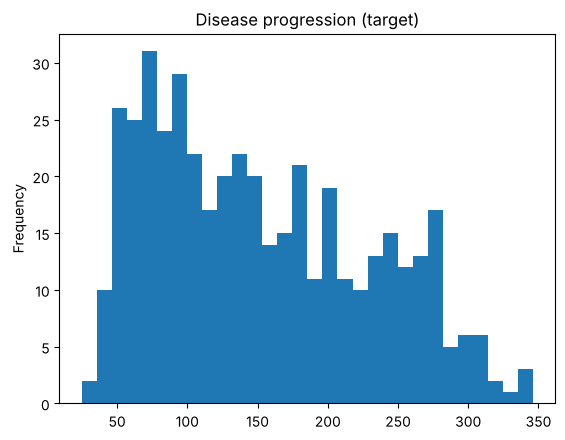

In [77]:
df['target'].plot.hist(bins=30, title='Disease progression (target)');

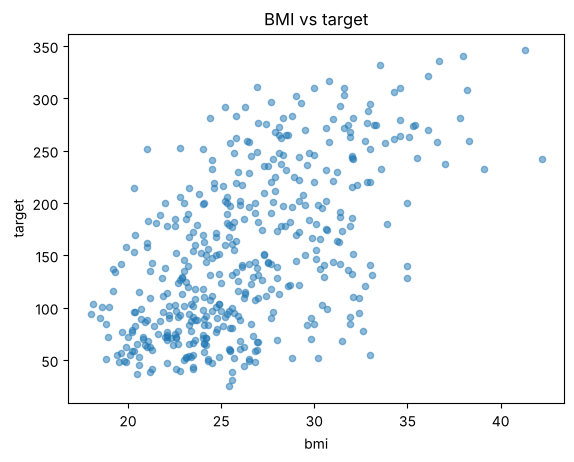

In [78]:
df.plot.scatter(x='bmi', y='target', alpha=0.5, title='BMI vs target');

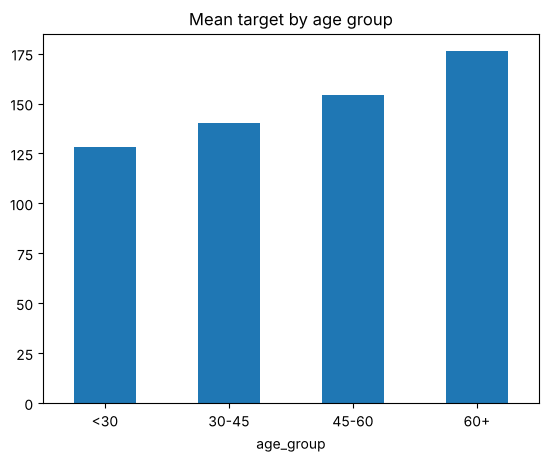

In [79]:
d.groupby('age_group', observed=True)['target'].mean().plot.bar(rot=0, title='Mean target by age group');

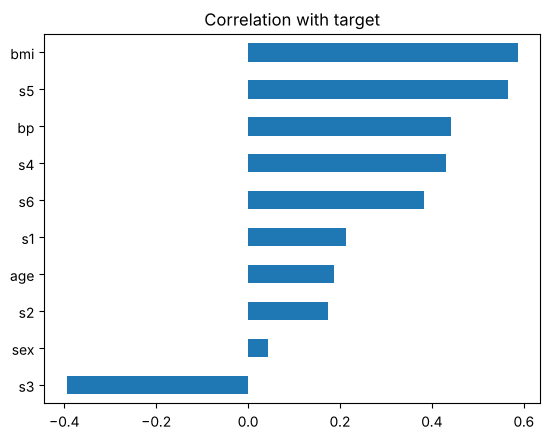

In [80]:
# correlation of each feature with the target
df.corr()['target'].drop('target').sort_values().plot.barh(title='Correlation with target');

bmi and s5 have the strongest relationship with the target, which matches what the scatter plot shows.

## Things that tripped me up

* `df[0:5]` slices rows, `df['col']` picks a column. Same brackets, different behaviour.
* `.loc` slices include the end label, `.iloc` slices don't.
* Use `&` `|` `~` with brackets around each condition, not `and` / `or`.
* `drop`, `rename`, `sort_values` etc. return a new frame. Assign the result back.
* Set values with `df.loc[mask, 'col'] = x`, not `df[mask]['col'] = x`.
* `groupby` alone doesn't compute anything. You need an aggregation after it.

## References

* [pandas cheat sheet (PDF)](https://pandas.pydata.org/Pandas_Cheat_Sheet.pdf)
* [10 minutes to pandas](https://pandas.pydata.org/docs/user_guide/10min.html)
* [pandas user guide](https://pandas.pydata.org/docs/user_guide/index.html)